In [28]:
library(tidyverse) 
library(caret)
library(glmnet)

#### 1. Data Exploration

In [29]:
data <- read_csv("/kaggle/input/datasets/ivancobarrubias/customer-segmentation/customer_segmentation.csv")
names(data) <- make.names(names(data))

Rows: 10532 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Gender, Product Category Purchased, Customer Segment
dbl (5): Customer ID, Age, Annual Income (K$), Average Spend per Visit ($), ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


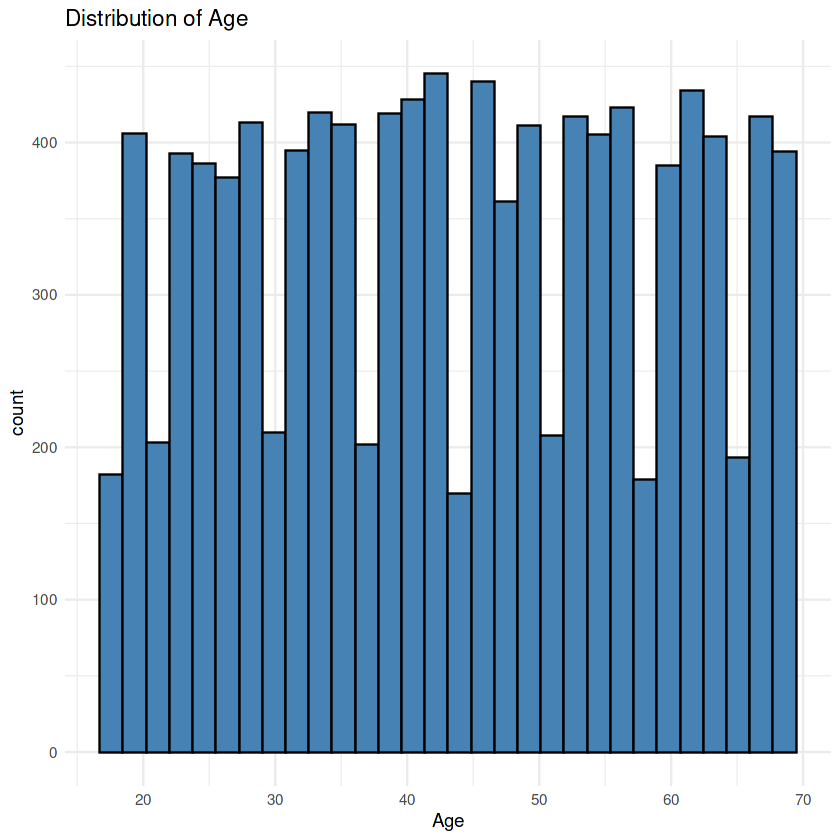

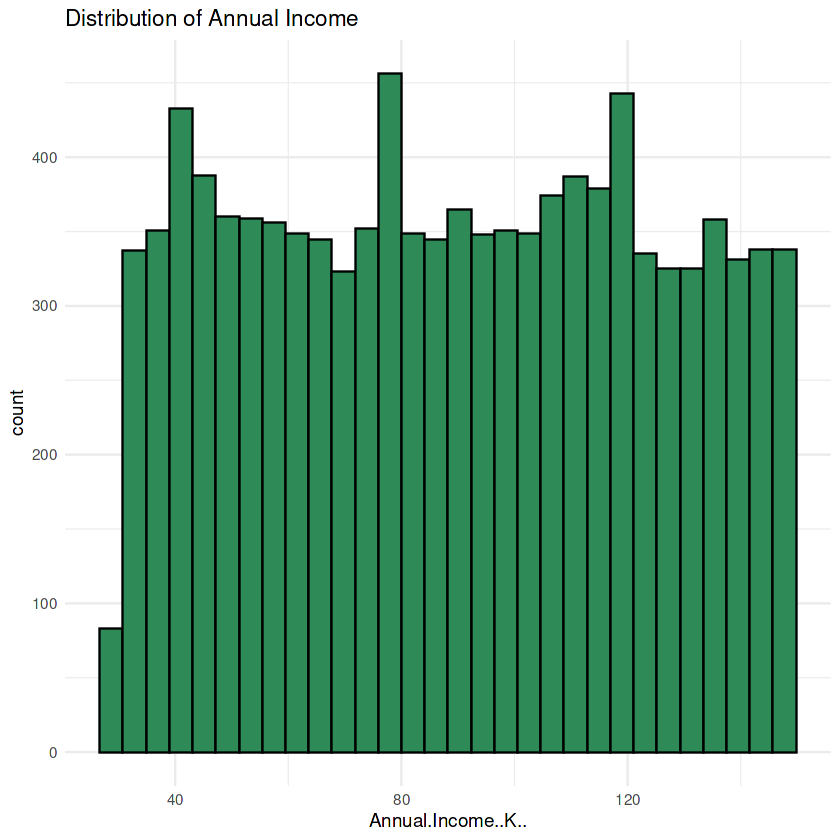

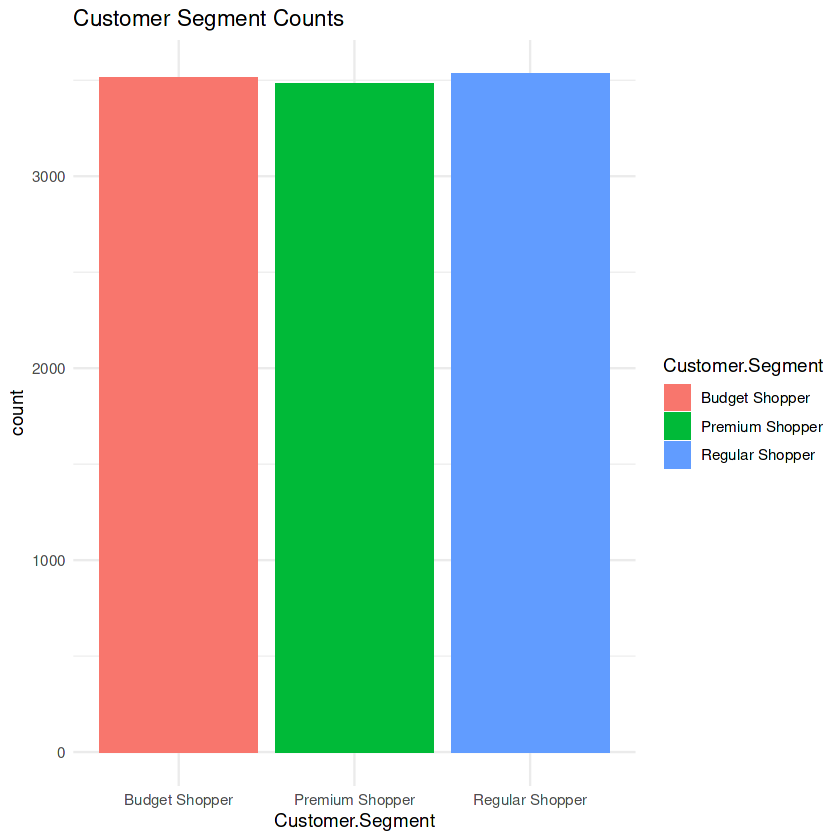

In [30]:
data <- drop_na(data)

p1 <- ggplot(data, aes(x = Age)) + 
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  theme_minimal() + ggtitle("Distribution of Age")
p2 <- ggplot(data, aes(x = Annual.Income..K..)) + 
  geom_histogram(bins = 30, fill = "seagreen", color = "black") +
  theme_minimal() + ggtitle("Distribution of Annual Income")
p3 <- ggplot(data, aes(x = Customer.Segment, fill=Customer.Segment)) + 
  geom_bar() + theme_minimal() + ggtitle("Customer Segment Counts")

print(p1)
print(p2)
print(p3)

#### 2. Data Preprocessing

In [31]:
data$Gender <- as.factor(data$Gender)
data$Product.Category.Purchased <- as.factor(data$Product.Category.Purchased)
data$Customer.Segment <- as.factor(data$Customer.Segment)

data <- data %>% select(-Customer.ID)

set.seed(42) 
trainIndex <- createDataPartition(data$Customer.Segment, p = 0.8, list = FALSE)
train_data <- data[trainIndex, ]
test_data  <- data[-trainIndex, ]

preProcValues <- preProcess(train_data[, c("Age", "Annual.Income..K..", "Average.Spend.per.Visit....")], 
                            method = c("center", "scale"))

train_data_scaled <- predict(preProcValues, train_data)
test_data_scaled  <- predict(preProcValues, test_data)

cat("Preprocessing complete. Training set size:", nrow(train_data_scaled), "\n")

Preprocessing complete. Training set size: 8427 


#### 3. Model Building

Optimal lambda (regularization strength): 8.249331 


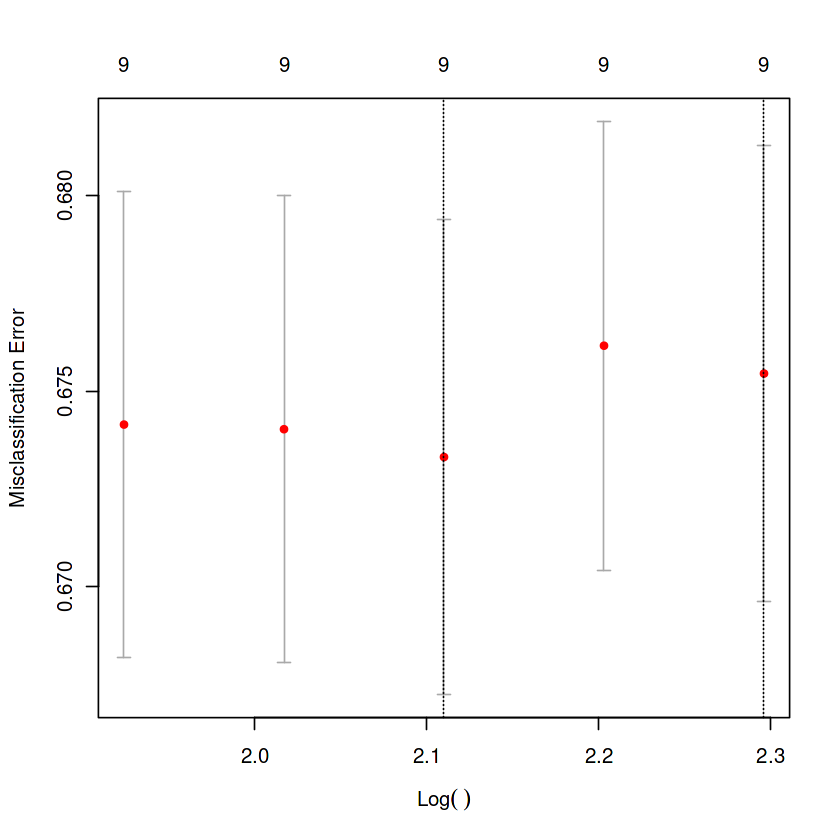

In [32]:
x_train <- model.matrix(Customer.Segment ~ ., data = train_data_scaled)[, -1] 
y_train <- train_data_scaled$Customer.Segment

cv_model <- cv.glmnet(x_train, y_train, family = "multinomial", alpha = 0, type.measure = "class")

plot(cv_model)
cat("Optimal lambda (regularization strength):", cv_model$lambda.min, "\n")

#### 4. Model Evaluation

In [33]:
x_test <- model.matrix(Customer.Segment ~ ., data = test_data_scaled)[, -1]
y_test <- test_data_scaled$Customer.Segment

predictions <- predict(cv_model, newx = x_test, s = "lambda.min", type = "class")
predictions <- as.factor(as.vector(predictions))

conf_matrix <- confusionMatrix(predictions, y_test)
print(conf_matrix)

coef_premium <- coef(cv_model, s = "lambda.min")[["Premium Shopper"]]
cat("\n--- Coefficients for Premium Shopper ---\n")
print(coef_premium)

Warning message in levels(reference) != levels(data):
“longer object length is not a multiple of shorter object length”
Warning message in confusionMatrix.default(predictions, y_test):
“Levels are not in the same order for reference and data. Refactoring data to match.”


Confusion Matrix and Statistics

                 Reference
Prediction        Budget Shopper Premium Shopper Regular Shopper
  Budget Shopper              75              69              80
  Premium Shopper              0               0               0
  Regular Shopper            628             627             626

Overall Statistics
                                          
               Accuracy : 0.333           
                 95% CI : (0.3129, 0.3536)
    No Information Rate : 0.3354          
    P-Value [Acc > NIR] : 0.5993          
                                          
                  Kappa : -0.0033         
                                          
 Mcnemar's Test P-Value : <2e-16          

Statistics by Class:

                     Class: Budget Shopper Class: Premium Shopper
Sensitivity                        0.10669                 0.0000
Specificity                        0.89372                 1.0000
Pos Pred Value                     0.33482          

#### 5. Refinement

In [35]:
train_data_scaled$Age_Income_Interaction <- train_data_scaled$Age * train_data_scaled$Annual.Income..K..
test_data_scaled$Age_Income_Interaction <- test_data_scaled$Age * test_data_scaled$Annual.Income..K..

x_train_interact <- model.matrix(Customer.Segment ~ ., data = train_data_scaled)[, -1]
x_test_interact <- model.matrix(Customer.Segment ~ ., data = test_data_scaled)[, -1]

cv_model_interact <- cv.glmnet(x_train_interact, y_train, family = "multinomial", alpha = 0, type.measure = "class")

predictions_interact <- predict(cv_model_interact, newx = x_test_interact, s = "lambda.min", type = "class")
conf_matrix_interact <- confusionMatrix(as.factor(as.vector(predictions_interact)), y_test)

cat("\nAccuracy WITHOUT interaction feature:", conf_matrix$overall['Accuracy'], "\n")
cat("Accuracy WITH interaction feature:", conf_matrix_interact$overall['Accuracy'], "\n")

Warning message in levels(reference) != levels(data):
“longer object length is not a multiple of shorter object length”
Warning message in confusionMatrix.default(as.factor(as.vector(predictions_interact)), :
“Levels are not in the same order for reference and data. Refactoring data to match.”



Accuracy WITHOUT interaction feature: 0.3330166 
Accuracy WITH interaction feature: 0.3353919 


#### 6. Reporting

A regularized multinomial logistic regression model was built through an R package (glmnet). The data was split into an 80% training set and a 20% testing set, with continuous variables centered and scaled.
The initial model achieved an overall accuracy of 33.44%. Because the dataset contains three relatively balanced customer segments, a 33% accuracy indicates that the model is performing no better than random chance. The confusion matrix further reveals that the model completely failed to predict the 'Premium Shopper' class, classifying the vast majority of all customers as 'Regular Shoppers'.

Despite the low overall predictive power, we can inspect the coefficients to see which features the model attempted to rely on. For the 'Premium Shopper' segment, the strongest positive feature relationships were:

Product Category - Fashion (Coefficient: 0.00147)  

Product Category - Electronics (Coefficient: 0.00084)  

Gender - Male (Coefficient: 0.00065)

An interaction term combining Age and Annual Income was introduced to capture potential non-linear relationships between a customer's age and their wealth. However, the cross-validated accuracy remained practically unchanged, improving only marginally to 33.54%.

In order to improve the model, exploring non-linear approaches might handle the complexity of the features.